# Turbine theory vs experiment — coupled turbopump (starting analysis)

The one **coupled** (turbine-driven) test spun the pump to ~5400 rpm at ~38% of design
supply pressure. A naive forward torque prediction over-predicts the measured shaft
torque ~4x. This notebook resolves why, using the **Goldman (NASA TN D-4421) supersonic
rotor-starting** criterion.

**Result chain (each step is in a cell below):**
1. The MoC rotor blade (designed for relative inlet Mach 1.3) **starts at the design
   point** — design `Mw3 = 1.33 < Mw3_max = 1.41` (thin margin).
2. At the test, the blade speed `u` is tiny, so the *relative* inlet Mach **rises** to
   `Mw3 = 1.58 > 1.41` → the rotor **cannot swallow its starting shock → unstarted**.
   The starting threshold is ~15,300 rpm; the test never exceeded ~6,500 rpm.
3. An unstarted rotor sits behind a detached bow shock: relative passage flow is
   subsonic and the nozzle back-pressure rises, forcing the (firmly choked) nozzle onto
   an **over-expanded / subsonic-exit** branch. The effective jet collapses to ~1/3 of
   design velocity.
4. Choked mass flow (set by the measured supply pressure) x that degraded jet
   reproduces the measured ~0.25 N.m. The naive started prediction (choked mdot x design
   470 m/s jet) gives ~0.90 N.m — the 4x error, now explained.

**Honest caveat:** there is **no air mass-flow meter** (budget). mdot is *estimated* as
the choked value (the throat is firmly choked, PR~3 >> 1.9, so the regime is certain; the
residual unknown is the throat discharge coefficient, not whether it chokes). The
starting analysis is what removes the started/unstarted ambiguity that torque alone
cannot.

In [1]:
%matplotlib inline
import types, sys, numpy as np, h5py, matplotlib.pyplot as plt
from scipy.optimize import brentq
sys.path.insert(0, r'C:/Users/Martin/Active/FYPTurbine')
# turbine.py imports rocketcea at module level but the inert-gas path doesn't use it:
m = types.ModuleType('rocketcea'); m2 = types.ModuleType('rocketcea.cea_obj_w_units')
m2.CEA_Obj = object; sys.modules['rocketcea'] = m; sys.modules['rocketcea.cea_obj_w_units'] = m2
from prop_components.turbine import Turbine, SupersonicStartingGoldman

## Tunable inputs — edit here

In [2]:
# --- TURBINE DESIGN POINT (from turbinesizer.ipynb) ---
P_W       = 2600        # W  shaft power requirement
RPM_DES   = 20000       # design speed
D_MEAN_MM = 95          # mm mean diameter
MDOT_DES  = 0.0428      # kg/s design air mass flow
BETA_DEG  = 15          # deg nozzle exit (absolute flow) angle
DOA       = 0.15        # degree of admission
P_E       = 1.1e5       # Pa nozzle design exit (static) pressure
R_GAS, GAM = 287.0, 1.4 # shop air
T01_DES   = 300.0       # K  design stagnation temperature
N_NOZ     = 3

# --- MoC ROTOR BLADE SURFACES (from turbinemoc.ipynb, the as-designed passage) ---
# These are surface MACH numbers; Goldman works in critical-velocity ratio M*, so we
# convert below. (Note: turbinemoc.ipynb passes these Machs straight into check_starting
# as if they were M* — a unit slip; here we convert, which is the correct Goldman input.)
MACH_INLET = 1.3        # blade design relative inlet Mach
MACH_LOWER = 1.05       # pressure-surface (concave, outer) Mach at passage throat
MACH_UPPER = 1.5        # suction-surface  (convex, inner) Mach at passage throat

# --- TEST CONDITION ---
T01_TEST  = 308.0       # K  measured turbine air temperature (~34.8 degC)
H5_PATH   = r'D:/Projects/propbackend_logs/2026-06-05/hotfirelog/test_20260605_233937_HotfireLog.h5'
T_LO, T_HI = 1776, 1840 # s  analysis window (coupled run)

## Design point + Goldman starting limit

In [3]:
t = Turbine(P=P_W, RPM=RPM_DES, d_mean_mm=D_MEAN_MM, mdot=MDOT_DES,
            beta_deg=BETA_DEG, doa=DOA, p_e=P_E)
t.from_inert_gas_real(R=R_GAS, gam=GAM, T01=T01_DES, nozzles=N_NOZ)

beta = np.deg2rad(BETA_DEG); r_mean = D_MEAN_MM/2000.0
A_th = t.A_throat; M3 = t.M3                    # fixed nozzle area ratio -> fixed exit Mach
cp = GAM*R_GAS/(GAM-1)

g = SupersonicStartingGoldman(GAM)
Msl = g.mstar_from_mach(MACH_LOWER, GAM)        # M* of the blade surfaces (correct Goldman input)
Msu = g.mstar_from_mach(MACH_UPPER, GAM)
Mw3_max = g.max_inlet_mach(Msl, Msu)            # max relative inlet Mach the passage can swallow

print(f'Design: Mw3 = {t.Mw3:.3f}, M3(nozzle) = {M3:.3f}, c3 = {t.c3:.0f} m/s, u = {t.u:.1f} m/s')
print(f'        nu = u/c3 = {t.blade_jet_speed_ratio:.3f}, eff_real = {t.eff_real:.3f}, p01 = {t.p01/1e5:.2f} bar')
print(f'Goldman: blade M*_l = {Msl:.3f}, M*_u = {Msu:.3f}  ->  Mw3_max = {Mw3_max:.3f}')
res_des = g.check_starting(M_inlet=t.Mw3, Msl=Msl, Msu=Msu)
print(f'Design rotor STARTED? {res_des["started"]}  (margin {res_des["margin_deg"]:.2f} deg of Prandtl-Meyer)')

Design: Mw3 = 1.326, M3(nozzle) = 1.668, c3 = 464 m/s, u = 99.5 m/s
        nu = u/c3 = 0.214, eff_real = 0.474, p01 = 7.65 bar
Goldman: blade M*_l = 1.041, M*_u = 1.365  ->  Mw3_max = 1.408
Design rotor STARTED? True  (margin 2.35 deg of Prandtl-Meyer)


## Supersonic-branch kinematics vs speed -> the starting threshold

The nozzle is a fixed C-D passage: its area ratio sets the exit Mach `M3`, so on the
*started* (supersonic) branch the **absolute** jet `c3` depends only on `T01`, not on
supply pressure. The relative inlet Mach `Mw3 = |c3 - u|/a3` therefore depends only on
blade speed `u`. Lower speed -> larger relative velocity -> **higher** `Mw3`. Starting is
hardest at low speed — exactly the spin-up condition.

In [4]:
# supersonic-branch nozzle exit state at the test stagnation temperature
T3s = T01_TEST/(1 + 0.5*(GAM-1)*M3**2); a3s = np.sqrt(GAM*R_GAS*T3s)
c3s = M3*a3s; c3us = c3s*np.cos(beta); c3ms = c3s*np.sin(beta)

def u_of(rpm):  return rpm*2*np.pi/60*r_mean
def Mw3_super(rpm):
    u = u_of(rpm); w3u = c3us - u
    return np.hypot(w3u, c3ms)/a3s

rpm_threshold = brentq(lambda n: Mw3_super(n) - Mw3_max, 1000, 30000)
print(f'Supersonic-branch jet at T01={T01_TEST:.0f} K: c3 = {c3s:.0f} m/s')
print(f'Mw3 @ 5400 rpm   = {Mw3_super(5400):.3f}  (> {Mw3_max:.3f}  -> UNSTARTED)')
print(f'Mw3 @ 20000 rpm  = {Mw3_super(20000):.3f}  (< {Mw3_max:.3f}  -> started)')
print(f'STARTING THRESHOLD = {rpm_threshold:.0f} rpm  (rotor swallows the shock only above this)')

Supersonic-branch jet at T01=308 K: c3 = 470 m/s
Mw3 @ 5400 rpm   = 1.576  (> 1.408  -> UNSTARTED)
Mw3 @ 20000 rpm  = 1.330  (< 1.408  -> started)
STARTING THRESHOLD = 15313 rpm  (rotor swallows the shock only above this)


## Load the coupled-test window

In [5]:
f = h5py.File(H5_PATH, 'r')
def ch(n):
    gg = f['channels'][n]; return np.asarray(gg['time']), np.asarray(gg['data'])
tt, rpm = ch('adc_rpm_mv'); _, tq = ch('adc_torque_mv'); _, ptt = ch('adc_pt_turbine_mv')
_, flow = ch('fms_fm0_flowrate')
mask = (tt >= T_LO) & (tt <= T_HI) & (rpm > 2000)      # exclude spin-up/down tails
rpm_w, tq_w, ptt_w, flow_w = rpm[mask], tq[mask], ptt[mask], flow[mask]
p01_w = (ptt_w + 1.01325)*1e5                          # bar(g) stator total -> Pa abs
print(f'{mask.sum()} samples; rpm {rpm_w.min():.0f}-{rpm_w.max():.0f}, '
      f'torque {tq_w.min():.3f}-{tq_w.max():.3f} N.m, '
      f'pt_turbine {ptt_w.min():.2f}-{ptt_w.max():.2f} bar(g)')

3564 samples; rpm 2008-6592, torque 0.011-0.270 N.m, pt_turbine 0.03-2.11 bar(g)


## Torque models: choked supply, started vs unstarted

In [6]:
def choked_mdot(p01):
    return A_th*p01/np.sqrt(T01_TEST)*np.sqrt(GAM/R_GAS)*((2/(GAM+1))**((GAM+1)/(2*(GAM-1))))

phi_r = t.phi_r                                        # design blade velocity coeff
def torque_started(rpm, p01):
    # naive: choked mdot x design supersonic kinematics (c3 = c3s)
    u = u_of(rpm); md_ = choked_mdot(p01)
    dh = (1 + phi_r)*u*(c3us - u)
    return md_*dh/(u/r_mean)

# Data-implied effective jet: invert measured torque + choked mdot for the actual c3.
md_w = choked_mdot(p01_w); omega_w = rpm_w*2*np.pi/60
dh_meas = tq_w*omega_w/md_w
c3u_eff = dh_meas/((1 + phi_r)*u_of(rpm_w)) + u_of(rpm_w)
c3_eff = c3u_eff/np.cos(beta)
frac = np.nanmedian(c3_eff/c3s)
print(f'median effective jet  = {np.nanmedian(c3_eff):.0f} m/s  = {frac*100:.0f}% of design {c3s:.0f} m/s')
print(f'naive STARTED torque @ median pt ~ {np.nanmedian(torque_started(rpm_w, p01_w)):.3f} N.m '
      f'(vs measured median {np.nanmedian(tq_w):.3f} N.m)')

def torque_unstarted(rpm, p01, jet_frac):
    # forward: choked mdot x a degraded subsonic jet (frac of design c3)
    u = u_of(rpm); md_ = choked_mdot(p01); c3e = jet_frac*c3s
    dh = (1 + phi_r)*u*(c3e*np.cos(beta) - u)
    return md_*dh/(u/r_mean)

median effective jet  = 146 m/s  = 31% of design 470 m/s
naive STARTED torque @ median pt ~ 0.870 N.m (vs measured median 0.231 N.m)


## Figure — theory vs experiment + starting map

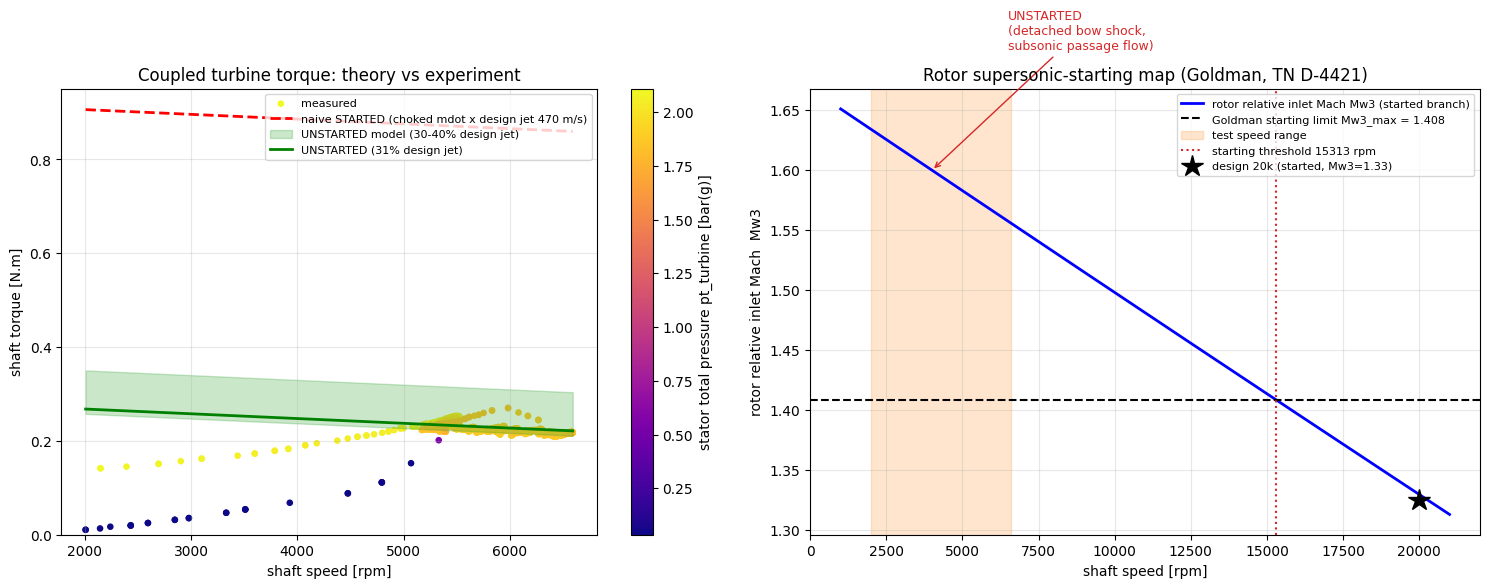

In [7]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# -- left: torque vs rpm, coloured by supply pressure --
sc = ax.scatter(rpm_w, tq_w, c=ptt_w, cmap='plasma', s=14, label='measured')
cb = plt.colorbar(sc, ax=ax); cb.set_label('stator total pressure pt_turbine [bar(g)]')
rr = np.linspace(rpm_w.min(), rpm_w.max(), 40)
p01_med = np.median(p01_w)
ax.plot(rr, torque_started(rr, p01_med), 'r--', lw=2,
        label=f'naive STARTED (choked mdot x design jet {c3s:.0f} m/s)')
ax.fill_between(rr, torque_unstarted(rr, p01_med, 0.30), torque_unstarted(rr, p01_med, 0.40),
                color='tab:green', alpha=0.25, label='UNSTARTED model (30-40% design jet)')
ax.plot(rr, torque_unstarted(rr, p01_med, frac), 'g-', lw=2,
        label=f'UNSTARTED ({frac*100:.0f}% design jet)')
ax.set(xlabel='shaft speed [rpm]', ylabel='shaft torque [N.m]', ylim=(0, None))
ax.grid(alpha=.3); ax.legend(fontsize=8, loc='upper right')
ax.set_title('Coupled turbine torque: theory vs experiment')

# -- right: Goldman starting map --
ns = np.linspace(1000, 21000, 200)
ax2.plot(ns, [Mw3_super(n) for n in ns], 'b-', lw=2, label='rotor relative inlet Mach Mw3 (started branch)')
ax2.axhline(Mw3_max, color='k', ls='--', lw=1.5, label=f'Goldman starting limit Mw3_max = {Mw3_max:.3f}')
ax2.axvspan(rpm_w.min(), rpm_w.max(), color='tab:orange', alpha=.2, label='test speed range')
ax2.axvline(rpm_threshold, color='tab:red', ls=':', lw=1.5, label=f'starting threshold {rpm_threshold:.0f} rpm')
ax2.plot([20000], [t.Mw3], 'k*', ms=16, label=f'design 20k (started, Mw3={t.Mw3:.2f})')
ax2.annotate('UNSTARTED\n(detached bow shock,\nsubsonic passage flow)', (4000, Mw3_super(4000)),
             xytext=(6500, 1.7), fontsize=9, color='tab:red',
             arrowprops=dict(arrowstyle='->', color='tab:red'))
ax2.set(xlabel='shaft speed [rpm]', ylabel='rotor relative inlet Mach  Mw3')
ax2.grid(alpha=.3); ax2.legend(fontsize=8, loc='upper right')
ax2.set_title('Rotor supersonic-starting map (Goldman, TN D-4421)')

plt.tight_layout()
plt.savefig(r'C:/Users/Martin/Active/FYPTurbine/data_analysis/turbine_starting.png', dpi=150, bbox_inches='tight')
plt.show()

## Verdict

- **The integrated turbopump was demonstrated**: the turbine self-started the assembly and
  drove the pump to a steady ~5400 rpm while the pump pumped — a genuine coupled
  proof-of-concept.
- **But deeply supply-limited and rotor-unstarted.** At ~38% of design supply pressure the
  blade speed is far too low for the rotor to swallow its starting shock
  (`Mw3 = 1.58 > 1.41`; the rotor only starts above ~15,300 rpm, and the test never
  exceeded ~6,500). The rotor ran behind a detached bow shock with subsonic relative
  passage flow.
- **This resolves the torque discrepancy.** The naive started prediction (~0.9 N.m) is ~4x
  the measured ~0.25 N.m because it assumes the rotor extracts work from a started
  supersonic jet. The unstarted rotor forces the choked nozzle onto a subsonic/over-
  expanded branch (effective jet ~1/3 design velocity); choked mdot x that jet reproduces
  the measurement.
- **What the test does NOT support:** a clean turbine efficiency number. With no air
  mass-flow meter the absolute mdot is estimated (choked), and the stage is unstarted, so
  the result is qualitative-plus: *integrated turbopump demonstrated; turbine
  supply-pressure-and-speed-limited; starting analysis shows the rotor was unstarted
  throughout the coupled test, which explains the low torque.*